# E-Commerce Sales Analytics using DuckDB

## Project Overview

This project analyzes e-commerce sales data using DuckDB and SQL.

The dataset is provided in Parquet format and contains information about orders, customers, sales, payments, refunds, customer segments, acquisition channels, and geographic markets.

DuckDB is used as the analytical database engine to efficiently query and analyze the dataset using SQL.

The project focuses on calculating key sales metrics, performing aggregations and joins, analyzing customer and sales behavior, identifying trends, and generating business insights.


## Technologies Used

- **Python** — Data analysis and visualization
- **DuckDB** — SQL-based analytical database
- **Pandas** — Data manipulation
- **Matplotlib** — Data visualization
- **Parquet** — Source data format
- **Jupyter Notebook** — Project development and presentation


## Dataset Description

The dataset used in this project is:

`ecommerce-sales-v1.0.0-analysis.parquet`

The dataset contains approximately 100,000 records.

Important fields include:

| Column | Description |
|---|---|
| `order_id` | Unique identifier for an order |
| `ordered_at` | Date and time of the order |
| `order_status` | Status of the order |
| `customer_id` | Customer identifier |
| `country_code` | Country associated with the order |
| `acquisition_channel` | Channel through which the customer was acquired |
| `customer_segment` | Customer segment |
| `line_count` | Number of line items in the order |
| `units` | Number of units purchased |
| `subtotal` | Order subtotal |
| `tax_amount` | Tax charged |
| `shipping_amount` | Shipping charges |
| `gross_payment` | Gross payment amount |
| `refund_amount` | Amount refunded |
| `net_revenue` | Revenue after refunds |


## Project Workflow

The analysis follows the workflow below:

Parquet Dataset
        ↓

DuckDB
        ↓

Data Validation
        ↓

Data Cleaning
        ↓

SQL Analysis
        ↓

Aggregations & JOINs
        ↓

Sales Metrics
        ↓

Visualizations
        ↓

Business Insights
        ↓
        
Conclusion


In [1]:
import os

files = os.listdir("../data")

print(files)


['ecommerce-sales-v1.0.0-analysis.parquet']


In [2]:
import duckdb
import pandas as pd

con = duckdb.connect("ecommerce.duckdb")

print("DuckDB connected successfully!")


DuckDB connected successfully!


In [3]:
con.sql("""
    SELECT *
    FROM read_parquet('../data/ecommerce-sales-v1.0.0-analysis.parquet')
    LIMIT 10
""")


┌──────────┬──────────────────────┬──────────────┬─────────────┬──────────────┬─────────────────────┬──────────────────┬────────────┬───────┬──────────┬────────────┬─────────────────┬───────────────┬───────────────┬─────────────┐
│ order_id │      ordered_at      │ order_status │ customer_id │ country_code │ acquisition_channel │ customer_segment │ line_count │ units │ subtotal │ tax_amount │ shipping_amount │ gross_payment │ refund_amount │ net_revenue │
│ varchar  │       varchar        │   varchar    │   varchar   │   varchar    │       varchar       │     varchar      │   int64    │ int64 │ varchar  │  varchar   │     varchar     │    varchar    │    varchar    │   varchar   │
├──────────┼──────────────────────┼──────────────┼─────────────┼──────────────┼─────────────────────┼──────────────────┼────────────┼───────┼──────────┼────────────┼─────────────────┼───────────────┼───────────────┼─────────────┤
│ O0000001 │ 2025-05-09T16:24:59Z │ completed    │ C002898     │ US           │ 

In [4]:
con.sql("""
    DESCRIBE
    SELECT *
    FROM read_parquet('../data/ecommerce-sales-v1.0.0-analysis.parquet')
""")


┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ order_id            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ordered_at          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ order_status        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_id         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ country_code        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ acquisition_channel │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_segment    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ line_count          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ units               │ BIGINT      │ YES     │ NULL    │ NULL  

In [5]:
con.sql("""
    SELECT COUNT(*) AS total_rows
    FROM read_parquet('../data/ecommerce-sales-v1.0.0-analysis.parquet')
""")


┌────────────┐
│ total_rows │
│   int64    │
├────────────┤
│     100000 │
└────────────┘

In [6]:
con.sql("""
    SELECT *
    FROM read_parquet('../data/ecommerce-sales-v1.0.0-analysis.parquet')
    LIMIT 5
""")


┌──────────┬──────────────────────┬──────────────┬─────────────┬──────────────┬─────────────────────┬──────────────────┬────────────┬───────┬──────────┬────────────┬─────────────────┬───────────────┬───────────────┬─────────────┐
│ order_id │      ordered_at      │ order_status │ customer_id │ country_code │ acquisition_channel │ customer_segment │ line_count │ units │ subtotal │ tax_amount │ shipping_amount │ gross_payment │ refund_amount │ net_revenue │
│ varchar  │       varchar        │   varchar    │   varchar   │   varchar    │       varchar       │     varchar      │   int64    │ int64 │ varchar  │  varchar   │     varchar     │    varchar    │    varchar    │   varchar   │
├──────────┼──────────────────────┼──────────────┼─────────────┼──────────────┼─────────────────────┼──────────────────┼────────────┼───────┼──────────┼────────────┼─────────────────┼───────────────┼───────────────┼─────────────┤
│ O0000001 │ 2025-05-09T16:24:59Z │ completed    │ C002898     │ US           │ 

In [7]:
con.execute("""
CREATE OR REPLACE TABLE orders AS
SELECT *
FROM read_parquet('../data/ecommerce-sales-v1.0.0-analysis.parquet');
""")

print("Orders table created successfully!")


Orders table created successfully!


In [8]:
con.sql("""
SELECT *
FROM orders
LIMIT 10
""")


┌──────────┬──────────────────────┬──────────────┬─────────────┬──────────────┬─────────────────────┬──────────────────┬────────────┬───────┬──────────┬────────────┬─────────────────┬───────────────┬───────────────┬─────────────┐
│ order_id │      ordered_at      │ order_status │ customer_id │ country_code │ acquisition_channel │ customer_segment │ line_count │ units │ subtotal │ tax_amount │ shipping_amount │ gross_payment │ refund_amount │ net_revenue │
│ varchar  │       varchar        │   varchar    │   varchar   │   varchar    │       varchar       │     varchar      │   int64    │ int64 │ varchar  │  varchar   │     varchar     │    varchar    │    varchar    │   varchar   │
├──────────┼──────────────────────┼──────────────┼─────────────┼──────────────┼─────────────────────┼──────────────────┼────────────┼───────┼──────────┼────────────┼─────────────────┼───────────────┼───────────────┼─────────────┤
│ O0000001 │ 2025-05-09T16:24:59Z │ completed    │ C002898     │ US           │ 

In [9]:
con.sql("""
SELECT COUNT(*) AS total_orders
FROM orders
""")


┌──────────────┐
│ total_orders │
│    int64     │
├──────────────┤
│       100000 │
└──────────────┘

In [10]:
con.sql("""
DESCRIBE orders
""")


┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ order_id            │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ ordered_at          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ order_status        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_id         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ country_code        │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ acquisition_channel │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_segment    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ line_count          │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ units               │ BIGINT      │ YES     │ NULL    │ NULL  

In [11]:
con.execute("""
CREATE OR REPLACE TABLE clean_orders AS
SELECT
    order_id,
    TRY_CAST(ordered_at AS TIMESTAMP) AS ordered_at,
    order_status,
    customer_id,
    country_code,
    acquisition_channel,
    customer_segment,
    line_count,
    units,
    TRY_CAST(subtotal AS DECIMAL(12,2)) AS subtotal,
    TRY_CAST(tax_amount AS DECIMAL(12,2)) AS tax_amount,
    TRY_CAST(shipping_amount AS DECIMAL(12,2)) AS shipping_amount,
    TRY_CAST(gross_payment AS DECIMAL(12,2)) AS gross_payment,
    TRY_CAST(refund_amount AS DECIMAL(12,2)) AS refund_amount,
    TRY_CAST(net_revenue AS DECIMAL(12,2)) AS net_revenue
FROM orders;
""")

print("Clean analysis table created!")


Clean analysis table created!


In [12]:
con.sql("""
SELECT *
FROM clean_orders
LIMIT 10
""")


┌──────────┬─────────────────────┬──────────────┬─────────────┬──────────────┬─────────────────────┬──────────────────┬────────────┬───────┬───────────────┬───────────────┬─────────────────┬───────────────┬───────────────┬───────────────┐
│ order_id │     ordered_at      │ order_status │ customer_id │ country_code │ acquisition_channel │ customer_segment │ line_count │ units │   subtotal    │  tax_amount   │ shipping_amount │ gross_payment │ refund_amount │  net_revenue  │
│ varchar  │      timestamp      │   varchar    │   varchar   │   varchar    │       varchar       │     varchar      │   int64    │ int64 │ decimal(12,2) │ decimal(12,2) │  decimal(12,2)  │ decimal(12,2) │ decimal(12,2) │ decimal(12,2) │
├──────────┼─────────────────────┼──────────────┼─────────────┼──────────────┼─────────────────────┼──────────────────┼────────────┼───────┼───────────────┼───────────────┼─────────────────┼───────────────┼───────────────┼───────────────┤
│ O0000001 │ 2025-05-09 16:24:59 │ completed

In [13]:
con.sql("""
DESCRIBE clean_orders
""")


┌─────────────────────┬───────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │  column_type  │  null   │   key   │ default │  extra  │
│       varchar       │    varchar    │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼───────────────┼─────────┼─────────┼─────────┼─────────┤
│ order_id            │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ ordered_at          │ TIMESTAMP     │ YES     │ NULL    │ NULL    │ NULL    │
│ order_status        │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_id         │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ country_code        │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ acquisition_channel │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ customer_segment    │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ line_count          │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ units               │ BIGINT        │ 

In [14]:
con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(order_id) AS missing_order_id,
    COUNT(*) - COUNT(ordered_at) AS missing_order_date,
    COUNT(*) - COUNT(customer_id) AS missing_customer_id,
    COUNT(*) - COUNT(net_revenue) AS missing_net_revenue
FROM clean_orders;
""")


┌────────────┬──────────────────┬────────────────────┬─────────────────────┬─────────────────────┐
│ total_rows │ missing_order_id │ missing_order_date │ missing_customer_id │ missing_net_revenue │
│   int64    │      int64       │       int64        │        int64        │        int64        │
├────────────┼──────────────────┼────────────────────┼─────────────────────┼─────────────────────┤
│     100000 │                0 │                  0 │                   0 │                   0 │
└────────────┴──────────────────┴────────────────────┴─────────────────────┴─────────────────────┘

**Basic Sales Metrics**

In [15]:
con.sql("""
SELECT
    COUNT(DISTINCT order_id) AS total_orders
FROM clean_orders;
""")


┌──────────────┐
│ total_orders │
│    int64     │
├──────────────┤
│       100000 │
└──────────────┘

In [16]:
con.sql("""
SELECT
    SUM(units) AS total_units_sold
FROM clean_orders;
""")


┌──────────────────┐
│ total_units_sold │
│      int128      │
├──────────────────┤
│           328166 │
└──────────────────┘

In [17]:
con.sql("""
SELECT
    SUM(net_revenue) AS total_net_revenue
FROM clean_orders;
""")


┌───────────────────┐
│ total_net_revenue │
│   decimal(38,2)   │
├───────────────────┤
│       60070660.02 │
└───────────────────┘

In [18]:
con.sql("""
SELECT
    SUM(gross_payment) AS total_gross_payment
FROM clean_orders;
""")


┌─────────────────────┐
│ total_gross_payment │
│    decimal(38,2)    │
├─────────────────────┤
│         63458562.67 │
└─────────────────────┘

In [19]:
con.sql("""
SELECT
    SUM(refund_amount) AS total_refunds
FROM clean_orders;
""")


┌───────────────┐
│ total_refunds │
│ decimal(38,2) │
├───────────────┤
│    3387902.65 │
└───────────────┘

In [20]:
con.sql("""
SELECT
    SUM(net_revenue) / COUNT(DISTINCT order_id) AS average_order_value
FROM clean_orders;
""")


┌─────────────────────┐
│ average_order_value │
│       double        │
├─────────────────────┤
│         600.7066002 │
└─────────────────────┘

In [21]:
kpi = con.sql("""
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units_sold,
    ROUND(SUM(gross_payment), 2) AS gross_sales,
    ROUND(SUM(refund_amount), 2) AS total_refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue,
    ROUND(
        SUM(net_revenue) / COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM clean_orders;
""").df()

kpi


,total_orders,total_units_sold,gross_sales,total_refunds,net_revenue,average_order_value
0,100000,328166.0,63458562.67,3387902.65,60070660.02,600.71


### Order Status Analysis


In [22]:
con.sql("""
SELECT
    order_status,
    COUNT(*) AS number_of_orders,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM clean_orders
GROUP BY order_status
ORDER BY number_of_orders DESC;
""")


┌────────────────────┬──────────────────┬────────────┐
│    order_status    │ number_of_orders │ percentage │
│      varchar       │      int64       │   double   │
├────────────────────┼──────────────────┼────────────┤
│ completed          │            89114 │      89.11 │
│ partially_refunded │             5217 │       5.22 │
│ cancelled          │             2976 │       2.98 │
│ refunded           │             2693 │       2.69 │
└────────────────────┴──────────────────┴────────────┘

In [23]:
con.sql("""
SELECT
    customer_segment,
    COUNT(DISTINCT order_id) AS orders,
    SUM(units) AS units_sold,
    ROUND(SUM(net_revenue), 2) AS revenue,
    ROUND(
        SUM(net_revenue) / COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM clean_orders
GROUP BY customer_segment
ORDER BY revenue DESC;
""")


┌──────────────────┬────────┬────────────┬───────────────┬─────────────────────┐
│ customer_segment │ orders │ units_sold │    revenue    │ average_order_value │
│     varchar      │ int64  │   int128   │ decimal(38,2) │       double        │
├──────────────────┼────────┼────────────┼───────────────┼─────────────────────┤
│ consumer         │  82134 │     269156 │   49301773.45 │              600.26 │
│ small_business   │  14909 │      49258 │    8960791.65 │              601.03 │
│ enterprise       │   2957 │       9752 │    1808094.92 │              611.46 │
└──────────────────┴────────┴────────────┴───────────────┴─────────────────────┘

In [24]:
con.sql("""
SELECT
    acquisition_channel,
    COUNT(DISTINCT order_id) AS orders,
    SUM(units) AS units_sold,
    ROUND(SUM(net_revenue), 2) AS revenue,
    ROUND(
        SUM(net_revenue) / COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM clean_orders
GROUP BY acquisition_channel
ORDER BY revenue DESC;
""")


┌─────────────────────┬────────┬────────────┬───────────────┬─────────────────────┐
│ acquisition_channel │ orders │ units_sold │    revenue    │ average_order_value │
│       varchar       │ int64  │   int128   │ decimal(38,2) │       double        │
├─────────────────────┼────────┼────────────┼───────────────┼─────────────────────┤
│ organic             │  30323 │      99196 │   18188790.59 │              599.83 │
│ paid_search         │  25140 │      82683 │   15125039.28 │              601.63 │
│ paid_social         │  19532 │      64482 │   11786285.45 │              603.43 │
│ referral            │  14836 │      48592 │    8870140.58 │              597.88 │
│ affiliate           │  10169 │      33213 │    6100404.12 │               599.9 │
└─────────────────────┴────────┴────────────┴───────────────┴─────────────────────┘

In [25]:
con.sql("""
SELECT
    country_code,
    COUNT(DISTINCT order_id) AS orders,
    SUM(units) AS units_sold,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
GROUP BY country_code
ORDER BY revenue DESC;
""")


┌──────────────┬────────┬────────────┬───────────────┐
│ country_code │ orders │ units_sold │    revenue    │
│   varchar    │ int64  │   int128   │ decimal(38,2) │
├──────────────┼────────┼────────────┼───────────────┤
│ US           │  63776 │     209211 │   38242421.08 │
│ GB           │  10178 │      33407 │    6102004.32 │
│ CA           │   9887 │      32590 │    6040015.03 │
│ AU           │   8209 │      26871 │    4895321.76 │
│ DE           │   7950 │      26087 │    4790897.83 │
└──────────────┴────────┴────────────┴───────────────┘

## Time-Based Sales Analysis

In [26]:
monthly_sales = con.sql("""
SELECT
    DATE_TRUNC('month', ordered_at) AS month,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
WHERE ordered_at IS NOT NULL
GROUP BY month
ORDER BY month;
""").df()

monthly_sales


,month,total_orders,total_units,revenue
0,2023-01-01,2697,8751.0,1630650.17
1,2023-02-01,2552,8475.0,1537253.34
2,2023-03-01,2943,9691.0,1816861.47
3,2023-04-01,2789,9176.0,1683330.66
4,2023-05-01,2858,9247.0,1655911.04
5,2023-06-01,2669,8670.0,1581325.51
6,2023-07-01,2865,9413.0,1692796.85
7,2023-08-01,2711,8873.0,1606803.99
8,2023-09-01,2707,9043.0,1638409.63
9,2023-10-01,2876,9479.0,1734189.03


Matplotlib is building the font cache; this may take a moment.


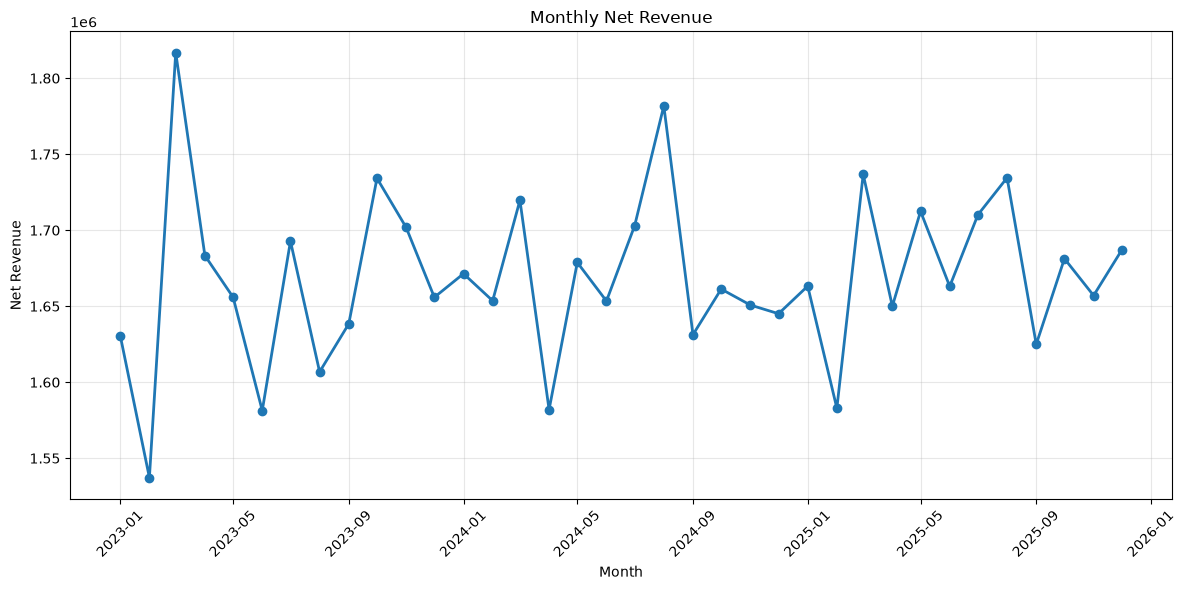

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Net Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


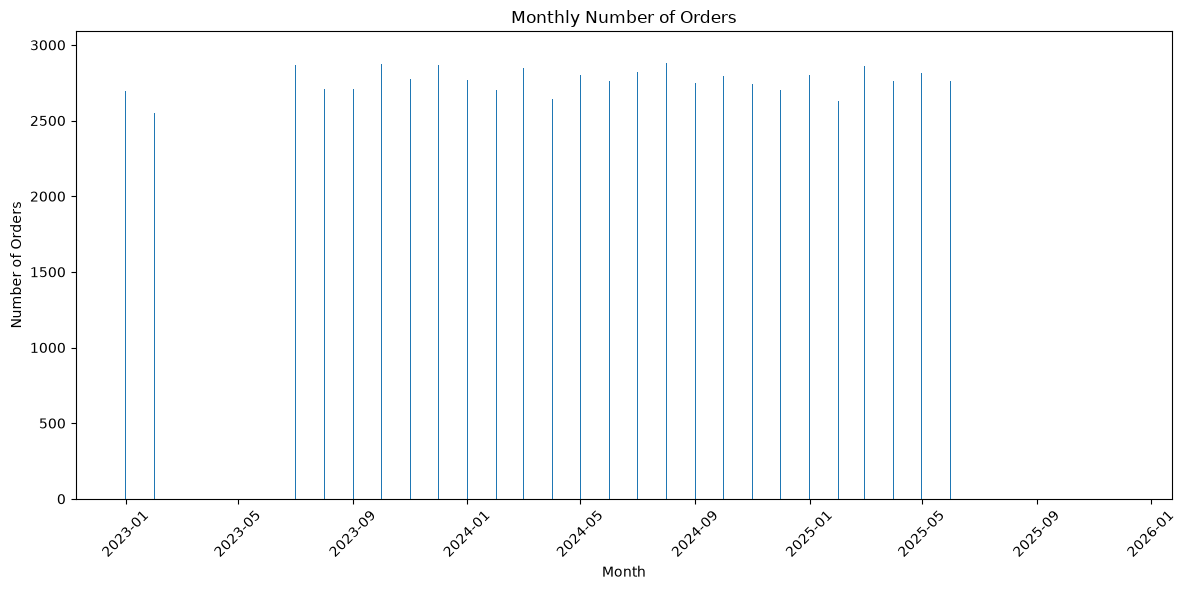

In [29]:
plt.figure(figsize=(12, 6))

plt.bar(
    monthly_sales["month"],
    monthly_sales["total_orders"]
)

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [30]:
monthly_growth = con.sql("""
WITH monthly AS (
    SELECT
        DATE_TRUNC('month', ordered_at) AS month,
        SUM(net_revenue) AS revenue
    FROM clean_orders
    WHERE ordered_at IS NOT NULL
    GROUP BY month
)

SELECT
    month,
    ROUND(revenue, 2) AS revenue,
    ROUND(
        LAG(revenue) OVER (ORDER BY month),
        2
    ) AS previous_month_revenue,
    ROUND(
        (
            (revenue - LAG(revenue) OVER (ORDER BY month))
            / NULLIF(LAG(revenue) OVER (ORDER BY month), 0)
        ) * 100,
        2
    ) AS growth_percentage
FROM monthly
ORDER BY month;
""").df()

monthly_growth


,month,revenue,previous_month_revenue,growth_percentage
0,2023-01-01,1630650.17,NaN,NaN
1,2023-02-01,1537253.34,1630650.17,-5.73
2,2023-03-01,1816861.47,1537253.34,18.19
3,2023-04-01,1683330.66,1816861.47,-7.35
4,2023-05-01,1655911.04,1683330.66,-1.63
5,2023-06-01,1581325.51,1655911.04,-4.50
6,2023-07-01,1692796.85,1581325.51,7.05
7,2023-08-01,1606803.99,1692796.85,-5.08
8,2023-09-01,1638409.63,1606803.99,1.97
9,2023-10-01,1734189.03,1638409.63,5.85


In [31]:
con.sql("""
SELECT
    DATE_TRUNC('month', ordered_at) AS month,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
WHERE ordered_at IS NOT NULL
GROUP BY month
ORDER BY revenue DESC
LIMIT 1;
""")


┌─────────────────────┬───────────────┐
│        month        │    revenue    │
│      timestamp      │ decimal(38,2) │
├─────────────────────┼───────────────┤
│ 2023-03-01 00:00:00 │    1816861.47 │
└─────────────────────┴───────────────┘

In [32]:
daily_sales = con.sql("""
SELECT
    CAST(ordered_at AS DATE) AS sales_date,
    COUNT(DISTINCT order_id) AS orders,
    SUM(units) AS units_sold,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
WHERE ordered_at IS NOT NULL
GROUP BY sales_date
ORDER BY sales_date;
""").df()

daily_sales.head(10)


,sales_date,orders,units_sold,revenue
0,2023-01-01,80,263.0,45974.26
1,2023-01-02,98,309.0,58605.98
2,2023-01-03,73,240.0,41318.17
3,2023-01-04,76,232.0,39821.41
4,2023-01-05,77,235.0,40705.97
5,2023-01-06,92,274.0,55183.04
6,2023-01-07,92,305.0,60546.94
7,2023-01-08,82,282.0,53195.53
8,2023-01-09,94,292.0,52195.55
9,2023-01-10,78,261.0,45514.39


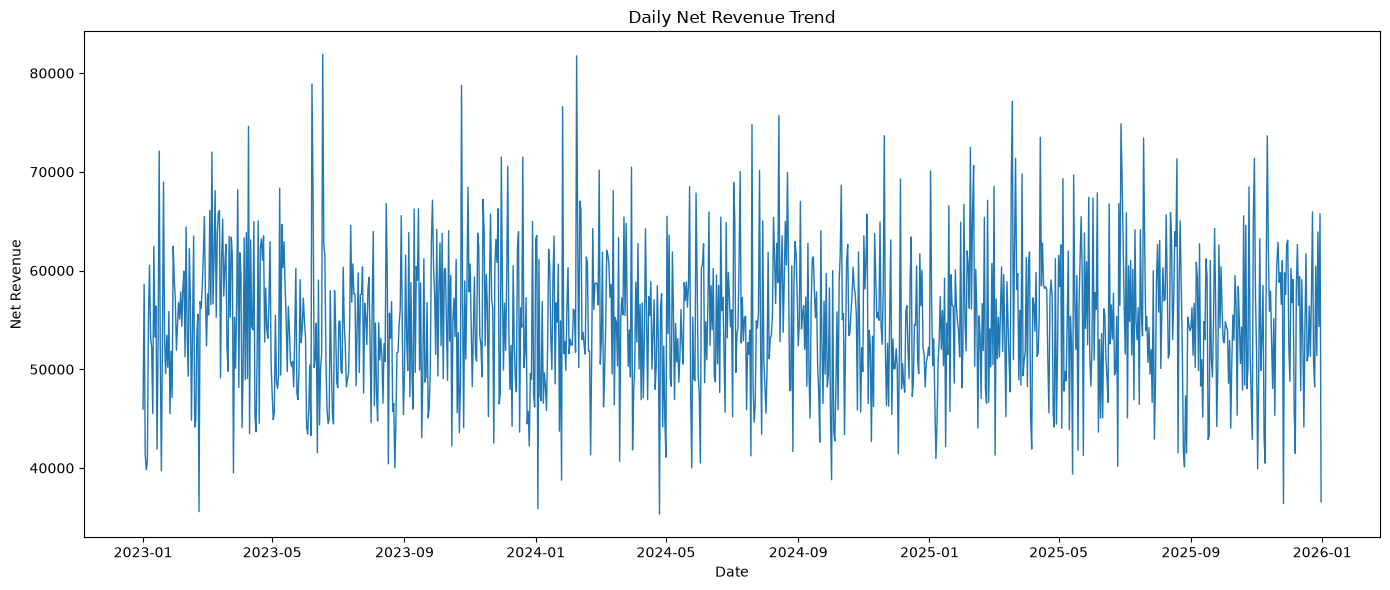

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["sales_date"],
    daily_sales["revenue"],
    linewidth=1
)

plt.title("Daily Net Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Net Revenue")

plt.tight_layout()
plt.show()


## Customer Analysis


In [34]:
customer_analysis = con.sql("""
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(net_revenue), 2) AS total_revenue,
    ROUND(
        SUM(net_revenue) / COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM clean_orders
GROUP BY customer_id
ORDER BY total_revenue DESC;
""").df()

customer_analysis.head(10)


,customer_id,total_orders,total_units,total_revenue,average_order_value
0,C000758,15,63.0,13836.62,922.44
1,C000221,13,58.0,12676.48,975.11
2,C000250,11,51.0,12671.47,1151.95
3,C005454,13,57.0,11850.94,911.61
4,C003038,9,47.0,11787.08,1309.68
5,C001273,10,54.0,11759.52,1175.95
6,C000947,11,50.0,11692.56,1062.96
7,C003717,14,54.0,11612.60,829.47
8,C002388,9,43.0,11530.06,1281.12
9,C000892,14,51.0,11428.49,816.32


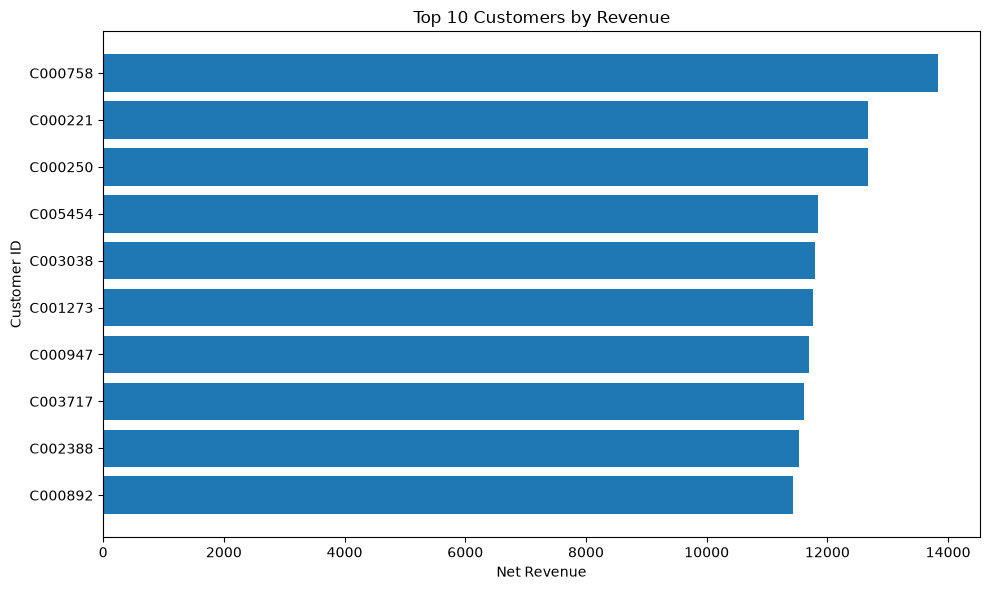

In [35]:
top_customers = customer_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_customers["customer_id"].astype(str),
    top_customers["total_revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## Customer Segment Analysis


In [36]:
segment_analysis = con.sql("""
SELECT
    customer_segment,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(gross_payment), 2) AS gross_revenue,
    ROUND(SUM(refund_amount), 2) AS refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue,
    ROUND(
        SUM(net_revenue) / COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM clean_orders
GROUP BY customer_segment
ORDER BY net_revenue DESC;
""").df()

segment_analysis


,customer_segment,total_orders,total_units,gross_revenue,refunds,net_revenue,average_order_value
0,consumer,82134,269156.0,52075730.68,2773957.23,49301773.45,600.26
1,small_business,14909,49258.0,9482924.84,522133.19,8960791.65,601.03
2,enterprise,2957,9752.0,1899907.15,91812.23,1808094.92,611.46


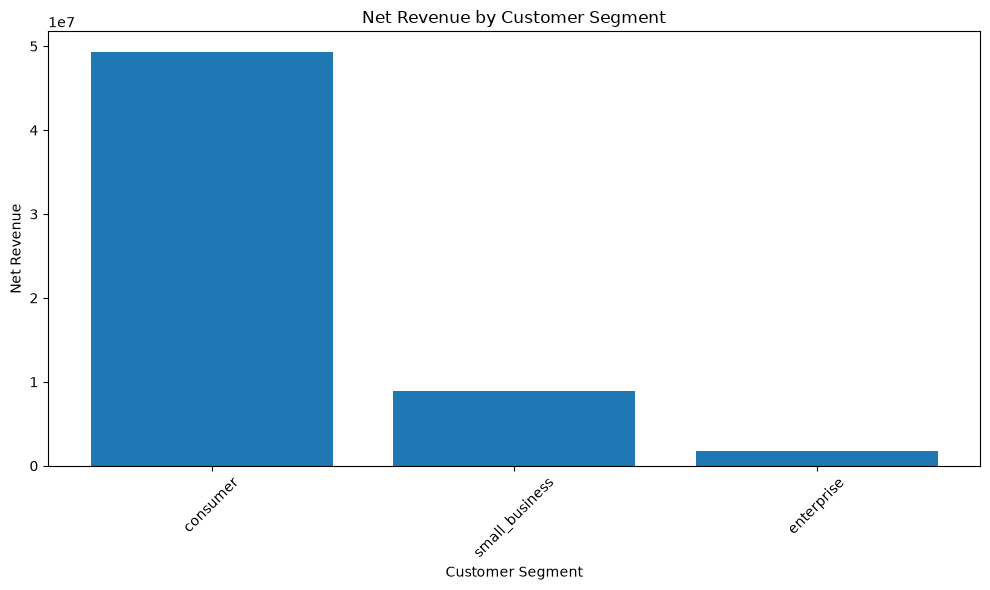

In [37]:
plt.figure(figsize=(10, 6))

plt.bar(
    segment_analysis["customer_segment"].astype(str),
    segment_analysis["net_revenue"]
)

plt.title("Net Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Geographic Sales Analysis


In [38]:
country_analysis = con.sql("""
SELECT
    country_code,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(gross_payment), 2) AS gross_revenue,
    ROUND(SUM(refund_amount), 2) AS refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue
FROM clean_orders
GROUP BY country_code
ORDER BY net_revenue DESC;
""").df()

country_analysis


,country_code,total_orders,total_units,gross_revenue,refunds,net_revenue
0,US,63776,209211.0,40450667.15,2208246.07,38242421.08
1,GB,10178,33407.0,6445292.29,343287.97,6102004.32
2,CA,9887,32590.0,6346508.94,306493.91,6040015.03
3,AU,8209,26871.0,5161414.57,266092.81,4895321.76
4,DE,7950,26087.0,5054679.72,263781.89,4790897.83


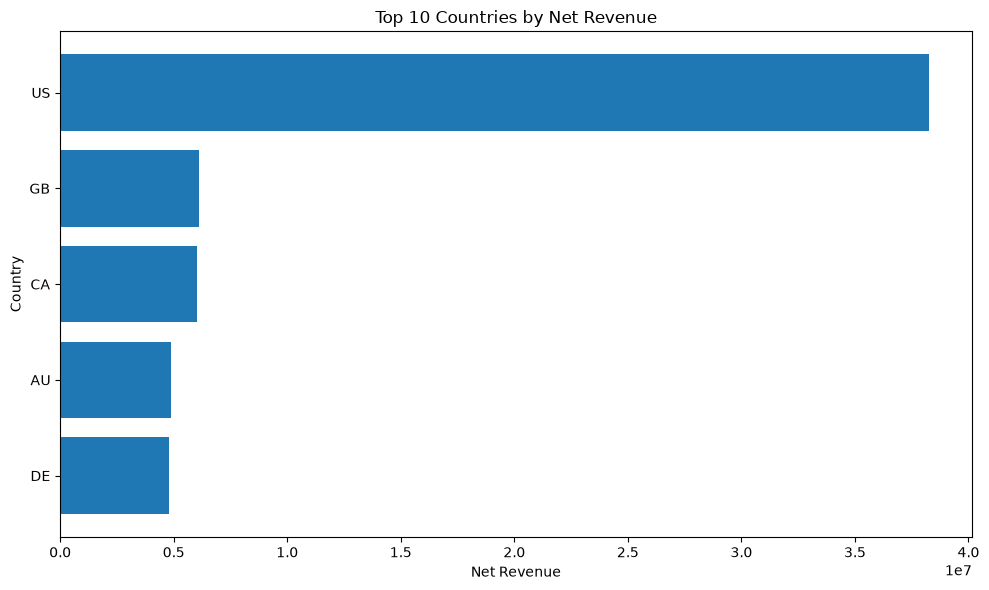

In [39]:
top_countries = country_analysis.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["country_code"].astype(str),
    top_countries["net_revenue"]
)

plt.title("Top 10 Countries by Net Revenue")
plt.xlabel("Net Revenue")
plt.ylabel("Country")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## Refund Analysis


In [40]:
refund_analysis = con.sql("""
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(
        DISTINCT CASE
            WHEN refund_amount > 0 THEN order_id
        END
    ) AS refunded_orders,
    ROUND(SUM(refund_amount), 2) AS total_refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue,
    ROUND(
        SUM(refund_amount) * 100.0
        / NULLIF(SUM(gross_payment), 0),
        2
    ) AS refund_rate_percentage
FROM clean_orders;
""").df()

refund_analysis


,total_orders,refunded_orders,total_refunds,net_revenue,refund_rate_percentage
0,100000,7910,3387902.65,60070660.02,5.34


In [41]:
con.sql("""
SELECT
    customer_segment,
    ROUND(SUM(gross_payment), 2) AS gross_revenue,
    ROUND(SUM(refund_amount), 2) AS refunds,
    ROUND(
        SUM(refund_amount) * 100.0
        / NULLIF(SUM(gross_payment), 0),
        2
    ) AS refund_rate
FROM clean_orders
GROUP BY customer_segment
ORDER BY refund_rate DESC;
""")


┌──────────────────┬───────────────┬───────────────┬─────────────┐
│ customer_segment │ gross_revenue │    refunds    │ refund_rate │
│     varchar      │ decimal(38,2) │ decimal(38,2) │   double    │
├──────────────────┼───────────────┼───────────────┼─────────────┤
│ small_business   │    9482924.84 │     522133.19 │        5.51 │
│ consumer         │   52075730.68 │    2773957.23 │        5.33 │
│ enterprise       │    1899907.15 │      91812.23 │        4.83 │
└──────────────────┴───────────────┴───────────────┴─────────────┘

In [42]:
con.sql("""
SELECT
    ROUND(SUM(subtotal), 2) AS total_subtotal,
    ROUND(SUM(tax_amount), 2) AS total_tax,
    ROUND(SUM(shipping_amount), 2) AS total_shipping,
    ROUND(SUM(gross_payment), 2) AS total_gross_payment,
    ROUND(SUM(refund_amount), 2) AS total_refunds,
    ROUND(SUM(net_revenue), 2) AS total_net_revenue
FROM clean_orders;
""")


┌────────────────┬───────────────┬────────────────┬─────────────────────┬───────────────┬───────────────────┐
│ total_subtotal │   total_tax   │ total_shipping │ total_gross_payment │ total_refunds │ total_net_revenue │
│ decimal(38,2)  │ decimal(38,2) │ decimal(38,2)  │    decimal(38,2)    │ decimal(38,2) │   decimal(38,2)   │
├────────────────┼───────────────┼────────────────┼─────────────────────┼───────────────┼───────────────────┤
│    60483519.62 │    4838681.57 │       42382.97 │         63458562.67 │    3387902.65 │       60070660.02 │
└────────────────┴───────────────┴────────────────┴─────────────────────┴───────────────┴───────────────────┘

In [43]:
status_analysis = con.sql("""
SELECT
    order_status,
    COUNT(DISTINCT order_id) AS orders,
    SUM(units) AS units,
    ROUND(SUM(gross_payment), 2) AS gross_payment,
    ROUND(SUM(refund_amount), 2) AS refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue
FROM clean_orders
GROUP BY order_status
ORDER BY net_revenue DESC;
""").df()

status_analysis


,order_status,orders,units,gross_payment,refunds,net_revenue
0,completed,89114,293094.0,58393630.56,0.00,58393630.56
1,partially_refunded,5217,16820.0,3351179.16,1674149.70,1677029.46
2,cancelled,2976,9635.0,0.00,0.00,0.00
3,refunded,2693,8617.0,1713752.95,1713752.95,0.00


In [44]:
con.sql("""
SELECT
    order_id,
    ordered_at,
    customer_id,
    country_code,
    customer_segment,
    units,
    ROUND(net_revenue, 2) AS net_revenue
FROM clean_orders
ORDER BY net_revenue DESC
LIMIT 10;
""")


┌──────────┬─────────────────────┬─────────────┬──────────────┬──────────────────┬───────┬───────────────┐
│ order_id │     ordered_at      │ customer_id │ country_code │ customer_segment │ units │  net_revenue  │
│ varchar  │      timestamp      │   varchar   │   varchar    │     varchar      │ int64 │ decimal(12,2) │
├──────────┼─────────────────────┼─────────────┼──────────────┼──────────────────┼───────┼───────────────┤
│ O0051603 │ 2025-06-02 19:13:21 │ C017613     │ AU           │ consumer         │    12 │       4742.76 │
│ O0005620 │ 2024-11-07 02:22:15 │ C015606     │ US           │ consumer         │    12 │       3860.92 │
│ O0043104 │ 2024-03-30 23:18:50 │ C009394     │ US           │ consumer         │    12 │       3719.52 │
│ O0022494 │ 2024-03-13 06:17:39 │ C002033     │ US           │ consumer         │    13 │       3703.01 │
│ O0073332 │ 2025-07-09 02:47:36 │ C001876     │ US           │ consumer         │    10 │       3692.75 │
│ O0032470 │ 2025-10-13 04:14:51 │ C0

In [45]:
repeat_customers = con.sql("""
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS order_count,
    ROUND(SUM(net_revenue), 2) AS total_revenue
FROM clean_orders
GROUP BY customer_id
HAVING COUNT(DISTINCT order_id) > 1
ORDER BY order_count DESC;
""").df()

repeat_customers.head(20)


,customer_id,order_count,total_revenue
0,C000028,16,7994.91
1,C005158,16,7146.18
2,C000274,15,7182.31
3,C006809,15,10028.83
4,C009584,15,7211.19
5,C000758,15,13836.62
6,C011004,14,7389.58
7,C003813,14,9019.06
8,C006374,14,9397.17
9,C009326,14,9715.81


In [46]:
con.sql("""
WITH customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS order_count
    FROM clean_orders
    GROUP BY customer_id
)

SELECT
    CASE
        WHEN order_count = 1 THEN 'One-time Customer'
        WHEN order_count BETWEEN 2 AND 5 THEN 'Repeat Customer'
        ELSE 'Frequent Customer'
    END AS customer_type,
    COUNT(*) AS customers
FROM customer_orders
GROUP BY customer_type
ORDER BY customers DESC;
""")


┌───────────────────┬───────────┐
│   customer_type   │ customers │
│      varchar      │   int64   │
├───────────────────┼───────────┤
│ Repeat Customer   │     11410 │
│ Frequent Customer │      7729 │
│ One-time Customer │       729 │
└───────────────────┴───────────┘

## SQL JOIN Analysis


In [47]:
con.execute("""
CREATE OR REPLACE TABLE customer_summary AS
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(gross_payment), 2) AS gross_spending,
    ROUND(SUM(refund_amount), 2) AS total_refunds,
    ROUND(SUM(net_revenue), 2) AS net_spending
FROM clean_orders
GROUP BY customer_id;
""")

print("Customer summary table created!")


Customer summary table created!


In [48]:
con.sql("""
SELECT *
FROM customer_summary
LIMIT 10;
""")


┌─────────────┬──────────────┬─────────────┬────────────────┬───────────────┬───────────────┐
│ customer_id │ total_orders │ total_units │ gross_spending │ total_refunds │ net_spending  │
│   varchar   │    int64     │   int128    │ decimal(38,2)  │ decimal(38,2) │ decimal(38,2) │
├─────────────┼──────────────┼─────────────┼────────────────┼───────────────┼───────────────┤
│ C002785     │            3 │           6 │         995.65 │          0.00 │        995.65 │
│ C012076     │            6 │          36 │        5753.94 │          0.00 │       5753.94 │
│ C016270     │            5 │          13 │        1853.03 │          0.00 │       1853.03 │
│ C019836     │            9 │          30 │        4795.20 │          0.00 │       4795.20 │
│ C007378     │            4 │          19 │        3837.63 │        404.62 │       3433.01 │
│ C012989     │            8 │          18 │        4274.83 │          0.00 │       4274.83 │
│ C006445     │            6 │          16 │        2099.22 

In [49]:
con.sql("""
SELECT
    o.order_id,
    o.ordered_at,
    o.customer_id,
    o.country_code,
    o.customer_segment,
    o.net_revenue,
    c.total_orders AS customer_total_orders,
    c.net_spending AS customer_total_spending
FROM clean_orders o
INNER JOIN customer_summary c
    ON o.customer_id = c.customer_id
LIMIT 20;
""")


┌──────────┬─────────────────────┬─────────────┬──────────────┬──────────────────┬───────────────┬───────────────────────┬─────────────────────────┐
│ order_id │     ordered_at      │ customer_id │ country_code │ customer_segment │  net_revenue  │ customer_total_orders │ customer_total_spending │
│ varchar  │      timestamp      │   varchar   │   varchar    │     varchar      │ decimal(12,2) │         int64         │      decimal(38,2)      │
├──────────┼─────────────────────┼─────────────┼──────────────┼──────────────────┼───────────────┼───────────────────────┼─────────────────────────┤
│ O0000001 │ 2025-05-09 16:24:59 │ C002898     │ US           │ consumer         │         30.56 │                     8 │                 5517.86 │
│ O0000002 │ 2025-12-12 08:14:21 │ C009320     │ AU           │ consumer         │          0.00 │                     6 │                 3973.56 │
│ O0000003 │ 2024-11-20 20:22:01 │ C015738     │ DE           │ consumer         │        510.28 │        

In [51]:
con.execute("""
CREATE OR REPLACE TABLE country_summary AS
SELECT
    country_code,
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(net_revenue), 2) AS total_revenue
FROM clean_orders
GROUP BY country_code;
""")


In [52]:
con.sql("""
SELECT *
FROM country_summary
ORDER BY total_revenue DESC;
""")


┌──────────────┬──────────────┬─────────────┬───────────────┐
│ country_code │ total_orders │ total_units │ total_revenue │
│   varchar    │    int64     │   int128    │ decimal(38,2) │
├──────────────┼──────────────┼─────────────┼───────────────┤
│ US           │        63776 │      209211 │   38242421.08 │
│ GB           │        10178 │       33407 │    6102004.32 │
│ CA           │         9887 │       32590 │    6040015.03 │
│ AU           │         8209 │       26871 │    4895321.76 │
│ DE           │         7950 │       26087 │    4790897.83 │
└──────────────┴──────────────┴─────────────┴───────────────┘

In [53]:
con.sql("""
SELECT
    o.order_id,
    o.customer_id,
    o.country_code,
    o.net_revenue,
    c.total_orders AS country_orders,
    c.total_units AS country_units,
    c.total_revenue AS country_revenue
FROM clean_orders o
INNER JOIN country_summary c
    ON o.country_code = c.country_code
LIMIT 20;
""")


┌──────────┬─────────────┬──────────────┬───────────────┬────────────────┬───────────────┬─────────────────┐
│ order_id │ customer_id │ country_code │  net_revenue  │ country_orders │ country_units │ country_revenue │
│ varchar  │   varchar   │   varchar    │ decimal(12,2) │     int64      │    int128     │  decimal(38,2)  │
├──────────┼─────────────┼──────────────┼───────────────┼────────────────┼───────────────┼─────────────────┤
│ O0000001 │ C002898     │ US           │         30.56 │          63776 │        209211 │     38242421.08 │
│ O0000002 │ C009320     │ AU           │          0.00 │           8209 │         26871 │      4895321.76 │
│ O0000003 │ C015738     │ DE           │        510.28 │           7950 │         26087 │      4790897.83 │
│ O0000004 │ C011513     │ US           │        355.91 │          63776 │        209211 │     38242421.08 │
│ O0000005 │ C011006     │ US           │        648.17 │          63776 │        209211 │     38242421.08 │
│ O0000006 │ C01435

In [54]:
customer_ranking = con.sql("""
SELECT
    customer_id,
    total_orders,
    total_units,
    net_spending,
    RANK() OVER (
        ORDER BY net_spending DESC
    ) AS revenue_rank
FROM customer_summary
ORDER BY revenue_rank
LIMIT 20;
""").df()

customer_ranking


,customer_id,total_orders,total_units,net_spending,revenue_rank
0,C000758,15,63.0,13836.62,1
1,C000221,13,58.0,12676.48,2
2,C000250,11,51.0,12671.47,3
3,C005454,13,57.0,11850.94,4
4,C003038,9,47.0,11787.08,5
5,C001273,10,54.0,11759.52,6
6,C000947,11,50.0,11692.56,7
7,C003717,14,54.0,11612.60,8
8,C002388,9,43.0,11530.06,9
9,C000892,14,51.0,11428.49,10


In [55]:
customer_value = con.sql("""
SELECT
    customer_id,
    total_orders,
    net_spending,
    CASE
        WHEN net_spending >= 5000 THEN 'High Value'
        WHEN net_spending >= 2000 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS value_category
FROM customer_summary
ORDER BY net_spending DESC;
""").df()

customer_value.head(20)


,customer_id,total_orders,net_spending,value_category
0,C000758,15,13836.62,High Value
1,C000221,13,12676.48,High Value
2,C000250,11,12671.47,High Value
3,C005454,13,11850.94,High Value
4,C003038,9,11787.08,High Value
5,C001273,10,11759.52,High Value
6,C000947,11,11692.56,High Value
7,C003717,14,11612.60,High Value
8,C002388,9,11530.06,High Value
9,C000892,14,11428.49,High Value


In [56]:
con.sql("""
SELECT
    CASE
        WHEN net_spending >= 5000 THEN 'High Value'
        WHEN net_spending >= 2000 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS value_category,
    COUNT(*) AS number_of_customers,
    ROUND(SUM(net_spending), 2) AS total_revenue
FROM customer_summary
GROUP BY value_category
ORDER BY total_revenue DESC;
""")


┌────────────────┬─────────────────────┬───────────────┐
│ value_category │ number_of_customers │ total_revenue │
│    varchar     │        int64        │ decimal(38,2) │
├────────────────┼─────────────────────┼───────────────┤
│ Medium Value   │               11051 │   36145426.35 │
│ High Value     │                2640 │   16478640.56 │
│ Low Value      │                6177 │    7446593.11 │
└────────────────┴─────────────────────┴───────────────┘

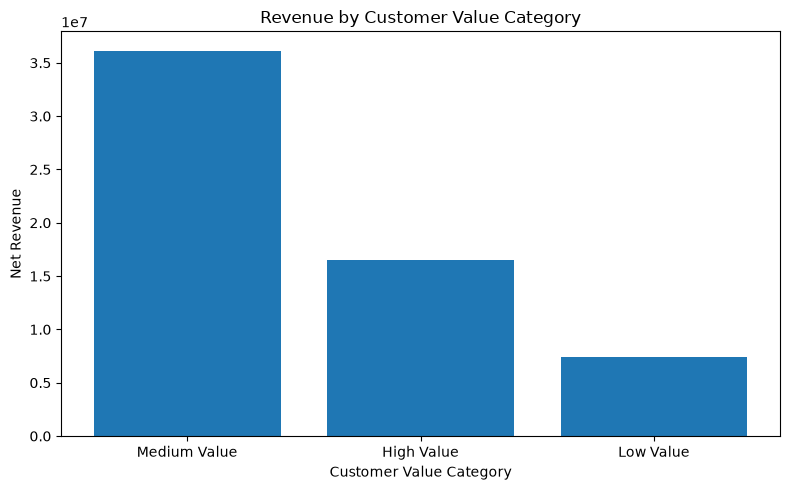

In [57]:
value_summary = con.sql("""
SELECT
    CASE
        WHEN net_spending >= 5000 THEN 'High Value'
        WHEN net_spending >= 2000 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS value_category,
    COUNT(*) AS number_of_customers,
    ROUND(SUM(net_spending), 2) AS total_revenue
FROM customer_summary
GROUP BY value_category
ORDER BY total_revenue DESC;
""").df()

plt.figure(figsize=(8, 5))

plt.bar(
    value_summary["value_category"],
    value_summary["total_revenue"]
)

plt.title("Revenue by Customer Value Category")
plt.xlabel("Customer Value Category")
plt.ylabel("Net Revenue")

plt.tight_layout()
plt.show()


In [58]:
overall_summary = con.sql("""
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units,
    ROUND(SUM(subtotal), 2) AS total_subtotal,
    ROUND(SUM(tax_amount), 2) AS total_tax,
    ROUND(SUM(shipping_amount), 2) AS total_shipping,
    ROUND(SUM(gross_payment), 2) AS gross_payment,
    ROUND(SUM(refund_amount), 2) AS total_refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue,
    ROUND(
        SUM(net_revenue) / COUNT(DISTINCT order_id),
        2
    ) AS average_order_value
FROM clean_orders;
""").df()

overall_summary


,total_orders,total_units,total_subtotal,total_tax,total_shipping,gross_payment,total_refunds,net_revenue,average_order_value
0,100000,328166.0,60483519.62,4838681.57,42382.97,63458562.67,3387902.65,60070660.02,600.71


In [59]:
top_segment = con.sql("""
SELECT
    customer_segment,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
GROUP BY customer_segment
ORDER BY revenue DESC
LIMIT 1;
""").df()

top_segment


,customer_segment,orders,revenue
0,consumer,82134,49301773.45


In [60]:
top_channel = con.sql("""
SELECT
    acquisition_channel,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
GROUP BY acquisition_channel
ORDER BY revenue DESC
LIMIT 1;
""").df()

top_channel


,acquisition_channel,orders,revenue
0,organic,30323,18188790.59


In [61]:
top_country = con.sql("""
SELECT
    country_code,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
GROUP BY country_code
ORDER BY revenue DESC
LIMIT 1;
""").df()

top_country


,country_code,orders,revenue
0,US,63776,38242421.08


In [62]:
best_month = con.sql("""
SELECT
    DATE_TRUNC('month', ordered_at) AS month,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
WHERE ordered_at IS NOT NULL
GROUP BY month
ORDER BY revenue DESC
LIMIT 1;
""").df()

best_month


,month,orders,revenue
0,2023-03-01,2943,1816861.47


In [63]:
top_customers = con.sql("""
SELECT
    customer_id,
    COUNT(DISTINCT order_id) AS orders,
    SUM(units) AS units,
    ROUND(SUM(net_revenue), 2) AS revenue
FROM clean_orders
GROUP BY customer_id
ORDER BY revenue DESC
LIMIT 10;
""").df()

top_customers


,customer_id,orders,units,revenue
0,C000758,15,63.0,13836.62
1,C000221,13,58.0,12676.48
2,C000250,11,51.0,12671.47
3,C005454,13,57.0,11850.94
4,C003038,9,47.0,11787.08
5,C001273,10,54.0,11759.52
6,C000947,11,50.0,11692.56
7,C003717,14,54.0,11612.60
8,C002388,9,43.0,11530.06
9,C000892,14,51.0,11428.49


In [64]:
refund_summary = con.sql("""
SELECT
    ROUND(SUM(gross_payment), 2) AS gross_payment,
    ROUND(SUM(refund_amount), 2) AS refunds,
    ROUND(
        SUM(refund_amount) * 100.0 /
        NULLIF(SUM(gross_payment), 0),
        2
    ) AS refund_rate_percentage
FROM clean_orders;
""").df()

refund_summary


,gross_payment,refunds,refund_rate_percentage
0,63458562.67,3387902.65,5.34


In [65]:
final_kpis = con.sql("""
SELECT
    COUNT(DISTINCT order_id) AS total_orders,
    SUM(units) AS total_units_sold,
    ROUND(SUM(gross_payment), 2) AS gross_payment,
    ROUND(SUM(refund_amount), 2) AS total_refunds,
    ROUND(SUM(net_revenue), 2) AS net_revenue,
    ROUND(
        SUM(net_revenue) /
        COUNT(DISTINCT order_id),
        2
    ) AS average_order_value,
    ROUND(
        SUM(refund_amount) * 100.0 /
        NULLIF(SUM(gross_payment), 0),
        2
    ) AS refund_rate
FROM clean_orders;
""").df()

final_kpis


,total_orders,total_units_sold,gross_payment,total_refunds,net_revenue,average_order_value,refund_rate
0,100000,328166.0,63458562.67,3387902.65,60070660.02,600.71,5.34


## Conclusion

This project demonstrated how DuckDB can be used to perform SQL-based analytics on an e-commerce dataset stored in Parquet format.

The analysis covered data validation, data cleaning, sales metrics, customer analysis, customer segmentation, acquisition channels, geographic performance, monthly sales trends, refund analysis, aggregations, and SQL JOIN operations.

The results provide an overview of sales performance and customer purchasing behavior and demonstrate how SQL and Python can be combined to transform raw e-commerce data into useful business insights.

Overall, the project shows the effectiveness of DuckDB for performing analytical queries directly on structured data using SQL.
